In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import joblib

import load.load_dataset as ds
import load.load_net as nt
import load.nets.training as tr

import torch
from sklearn.metrics import roc_auc_score, roc_curve

# **Tuning of hyperparameters to train model**

In [11]:
def plot_roc(y_val, results):
    y_val_labels = y_val.detach().numpy().argmax(axis=1)

    roc = roc_auc_score(y_val_labels, results['pred_proba'][0][:,1])
    fpr, tpr, _ = roc_curve(y_val_labels, results['pred_proba'][0][:,1])

    plt.figure(figsize=(6,6))
    plt.title(f'ROC AUC Curve - AUC: {roc:.4f}')
    plt.plot(fpr, tpr, color='blue', label='ROC')
    plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

In [12]:
def eval_net(dataset_name, model_name):
    
    history = joblib.load(f'./models/histories/{dataset_name}_{model_name}_history.joblib')
    axis = np.linspace(0, len(history['train_loss']), len(history['train_loss']))
    fig, ax = plt.subplots(1, 2, figsize = [12,5])
    ax[0].plot(axis, history['train_loss'], label='Train Loss')
    ax[0].plot(axis, history['val_loss'], label='Val Loss')
    ax[0].set_title('Loss')
    ax[0].legend()

    ax[1].plot(axis, history['train_acc'], label='Train Accuracy')
    ax[1].plot(axis, history['val_acc'], label='Val Accuracy')
    ax[1].set_title('Accuracy')
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    results = joblib.load(f'./models/results/{dataset_name}_{model_name}_results.joblib')
    print(results['classification_report'][0])
    return results


In [ ]:
dataset_name = "adult"
net = nt.load_net(dataset_name)
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal, discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()
print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(36177, 12) (8045, 12) (1000, 12)


### Adult - smallNN

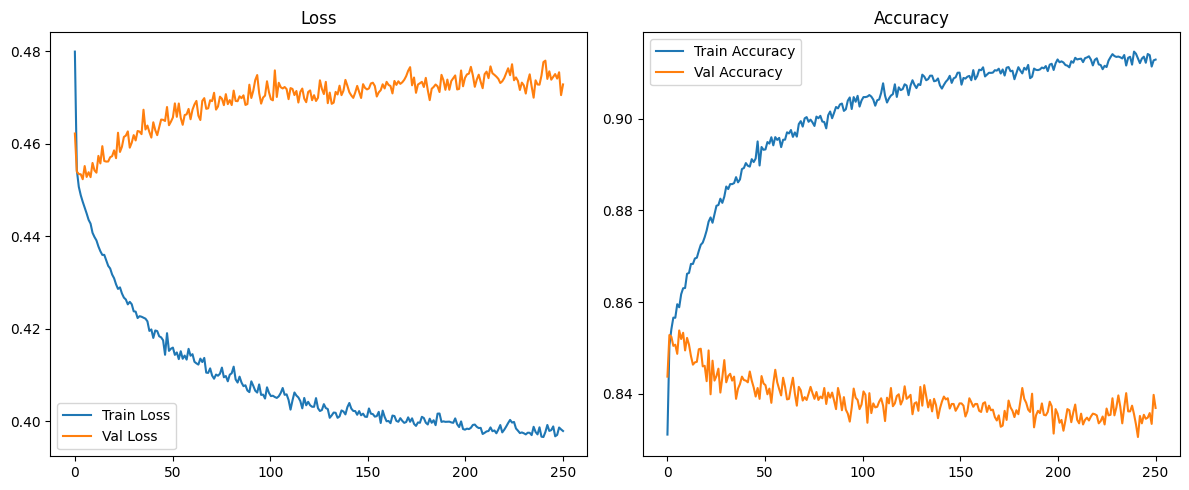

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      6033
           1       0.69      0.63      0.66      2012

    accuracy                           0.84      8045
   macro avg       0.79      0.77      0.78      8045
weighted avg       0.83      0.84      0.83      8045



In [14]:
result4 = eval_net(dataset_name, 'model4')

### Adult - RegularizedNN

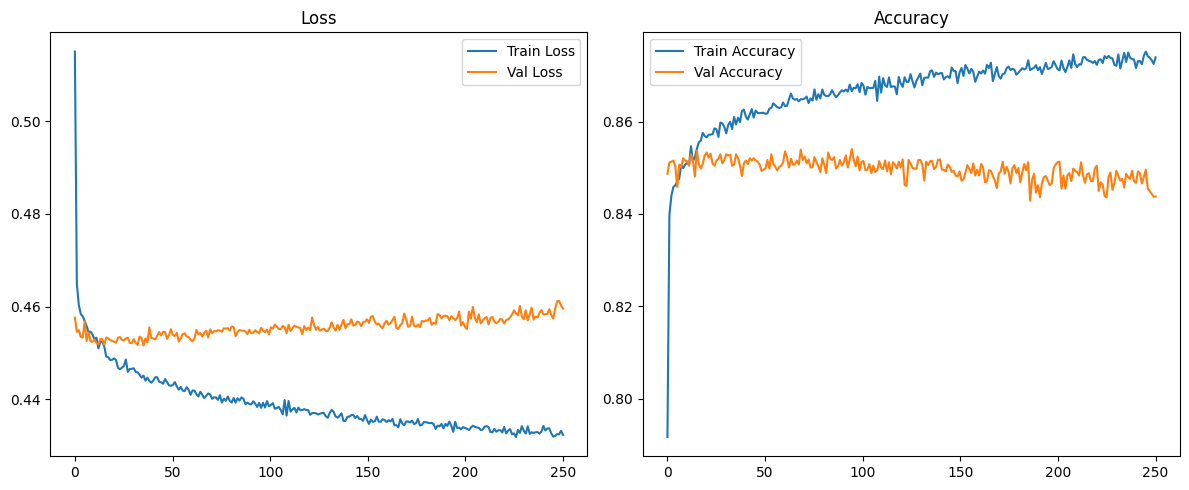

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      6033
           1       0.70      0.66      0.68      2012

    accuracy                           0.84      8045
   macro avg       0.79      0.78      0.79      8045
weighted avg       0.84      0.84      0.84      8045



In [15]:
result5 = eval_net(dataset_name, 'model5')

### Adult - BottleneckNN

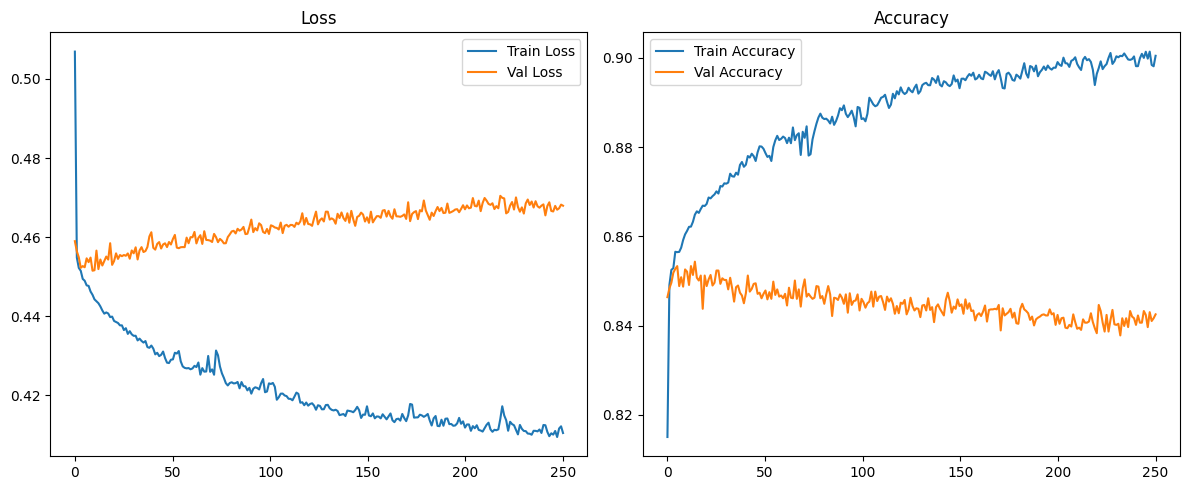

              precision    recall  f1-score   support

           0       0.87      0.92      0.90      6033
           1       0.72      0.60      0.66      2012

    accuracy                           0.84      8045
   macro avg       0.80      0.76      0.78      8045
weighted avg       0.84      0.84      0.84      8045



In [16]:
result6 = eval_net(dataset_name, 'model6')

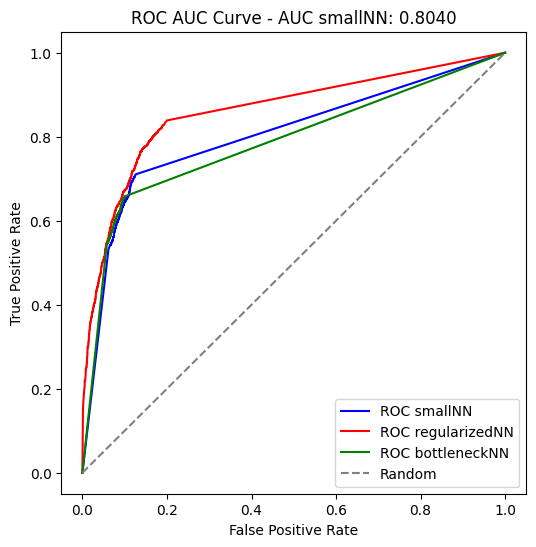

In [17]:
y_val_labels = y_val.detach().numpy().argmax(axis=1)

roc4 = roc_auc_score(y_val_labels, result4['pred_proba'][0][:,1])
fpr4, tpr4, _ = roc_curve(y_val_labels, result4['pred_proba'][0][:,1])
    
roc5 = roc_auc_score(y_val_labels, result5['pred_proba'][0][:,1])
fpr5, tpr5, _ = roc_curve(y_val_labels, result5['pred_proba'][0][:,1])
    
roc6 = roc_auc_score(y_val_labels, result6['pred_proba'][0][:,1])
fpr6, tpr6, _ = roc_curve(y_val_labels, result6['pred_proba'][0][:,1])

plt.figure(figsize=(6,6))
plt.title(f'ROC AUC Curve - AUC smallNN: {roc4:.4f}')
plt.plot(fpr4, tpr4, color='blue', label='ROC smallNN')
plt.plot(fpr5, tpr5, color='red', label='ROC regularizedNN')
plt.plot(fpr6, tpr6, color='green', label='ROC bottleneckNN')
plt.plot([0,1],[0,1], color='grey', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [18]:
model_dict = joblib.load(f"./load/nets/model_{dataset_name}_dict.joblib")
print(model_dict)

{'model1': smallNN(
  (linear1): Linear(in_features=97, out_features=256, bias=True)
  (sigmoid1): ReLU()
  (linear2): Linear(in_features=256, out_features=128, bias=True)
  (sigmoid2): ReLU()
  (linear3): Linear(in_features=128, out_features=64, bias=True)
  (sigmoid3): ReLU()
  (linear4): Linear(in_features=64, out_features=32, bias=True)
  (sigmoid4): ReLU()
  (linear5): Linear(in_features=32, out_features=2, bias=True)
  (softmax): Softmax(dim=None)
), 'model2': deeperNN(
  (linear1): Linear(in_features=97, out_features=1024, bias=True)
  (relu1): ReLU()
  (linear2): Linear(in_features=1024, out_features=512, bias=True)
  (relu2): ReLU()
  (linear3): Linear(in_features=512, out_features=128, bias=True)
  (relu3): ReLU()
  (linear4): Linear(in_features=128, out_features=64, bias=True)
  (relu4): ReLU()
  (linear5): Linear(in_features=64, out_features=32, bias=True)
  (relu5): ReLU()
  (linear6): Linear(in_features=32, out_features=2, bias=True)
  (softmax): Softmax(dim=None)
), 'mod